In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
import pandas as pd

# carregar dados
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')

# juntar dados
df = orders.merge(items, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(customers, on='customer_id')
df = df.merge(payments, on='order_id')

# mostrar dados
print(df.head())
print(df.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

Let's start by looking at the revenue generated.

In [3]:
print("Receita total:", df['payment_value'].sum())

Receita total: 20308134.709999997


The total revenue generated is approximately 20 million, indicating a high number of transactions generated during the analyzed period.

To get a better idea, let's look at this through a graph.

<Axes: title={'center': 'Receita por mês'}, xlabel='month'>

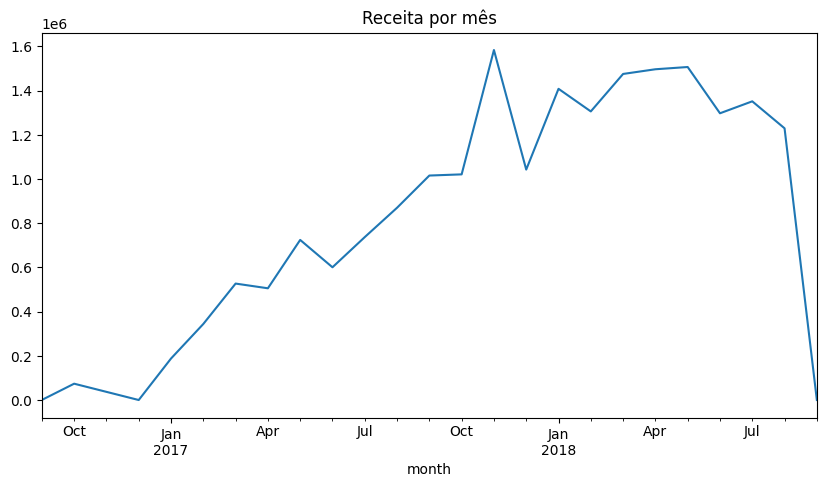

In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('month')['payment_value'].sum()

monthly.plot(figsize=(10,5), title='Receita por mês')

Revenue shows consistent growth, peaking in 2018. The sharp drop observed at the end of the analyzed period is likely due to incomplete data, not a real decline in sales.

We've already seen the revenue generated annually; now let's move on to seeing which product is the top seller.

<Axes: title={'center': 'Top produtos'}, xlabel='product_id'>

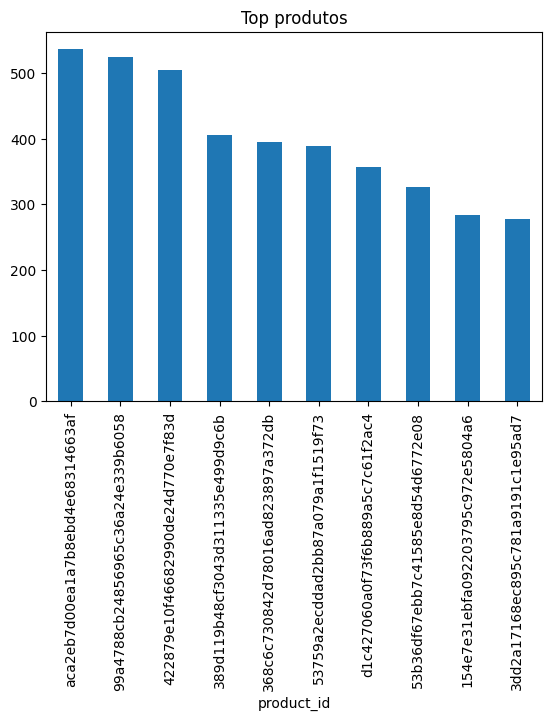

In [5]:
top_products = df['product_id'].value_counts().head(10)

top_products.plot(kind='bar', title='Top produtos')

As you can see, the product names are a bit strange, so let's fix that first.

<Axes: title={'center': 'Top categorias'}, xlabel='product_category_name_english'>

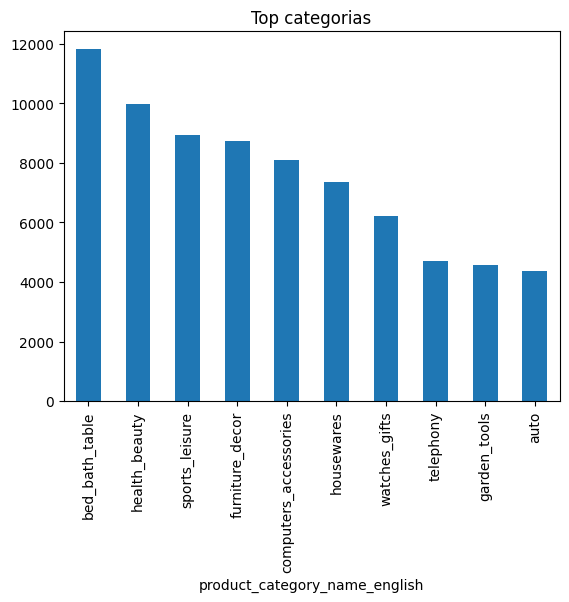

In [6]:
translation = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')

# juntar tradução
df = df.merge(translation, on='product_category_name', how='left')

# top categorias (MELHOR que product_id)
top_categories = df['product_category_name_english'].value_counts().head(10)

top_categories.plot(kind='bar', title='Top categorias')

Top-selling categories include bed_bath_table, health_beauty, and sports_leisure, We see that home and lifestyle are the main focus of e-commerce.

<Axes: title={'center': 'Top estados'}, xlabel='customer_state'>

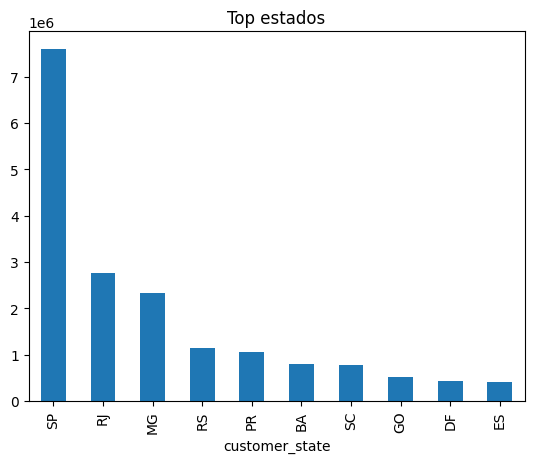

In [7]:
state_sales = df.groupby('customer_state')['payment_value'].sum()

state_sales.sort_values(ascending=False).head(10).plot(kind='bar', title='Top estados')

The state of São Paulo (SP) is undoubtedly the one that exerts the greatest influence on e-commerce, indicating a high concentration of customers.

In [8]:
top_customers = df.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False).head(10)

print(top_customers)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: payment_value, dtype: float64


A small group of customers spends over 100,000, accounting for a large portion of the revenue, which may indicate large-scale purchases or VIP customers. This suggests a concentration of revenue in a limited group of users.

In [9]:
df['delivery_time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

print("Tempo médio de entrega:", df['delivery_time'].mean())

Tempo médio de entrega: 12.018142462228559


The average delivery time is approximately 12 days, which may impact customer feedback depending on their expectations.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

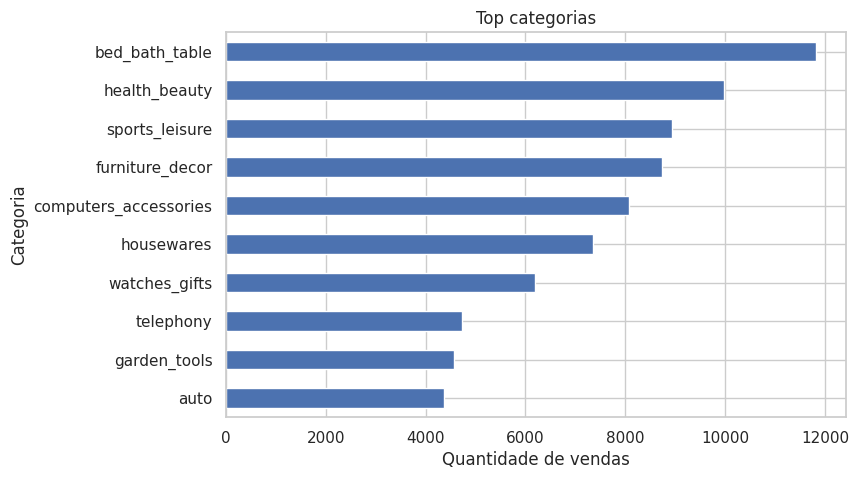

In [11]:
top_categories = df['product_category_name_english'].value_counts().head(10).sort_values()

top_categories.plot(kind='barh', figsize=(8,5), title='Top categorias')
plt.xlabel('Quantidade de vendas')
plt.ylabel('Categoria')
plt.show()

Another chart showing the dominance of the domestic market in e-commerce.

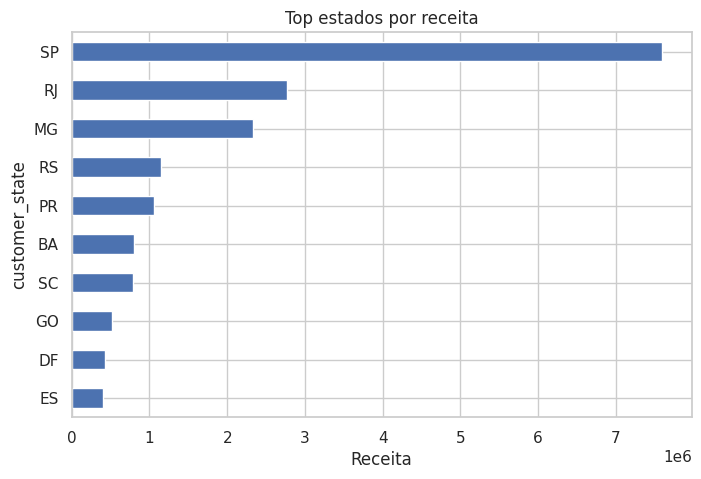

In [12]:
state_sales = df.groupby('customer_state')['payment_value'].sum().sort_values().tail(10)

state_sales.plot(kind='barh', figsize=(8,5), title='Top estados por receita')
plt.xlabel('Receita')
plt.show()

This further highlights how dominant the state of São Paulo (SP) is.